# INPUT
1. сканим разукрашку
2. выравниваем через ArUco маркеры
3. Вырезаем область с персонажем (bbox персонажа с отступами)
4. корректируем цвета фото
5. вырезаем персонажа <- Вы здесь

Есть два подхода:
1. Переносим цвета по контуру
    - Конутры могут ехать и получается двойные линии
    - Мб добавить больше ArUco маркеров (?)
2. Сегментация персонажа
    - Мы угадываем где контуры - артефакты и неправильная обрезка персонажа
        - типа грязные контуры и пр
    - Зато если успех, то контуры не едут

In [16]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Размер: 1454×940


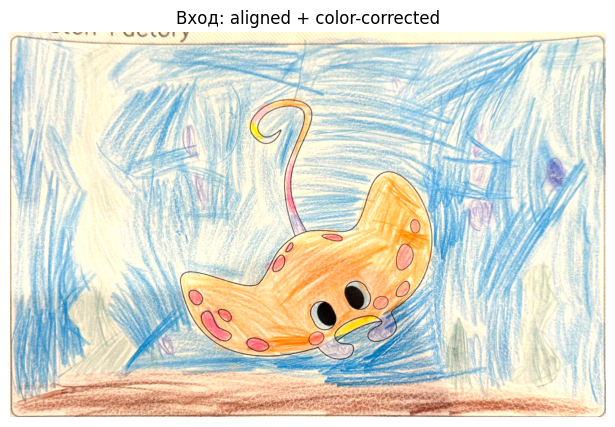

In [17]:
img = cv2.imread("input/seg_002.png")
print(f"Размер: {img.shape[1]}×{img.shape[0]}")

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Вход: aligned + color-corrected")
plt.show()

**бейзлайн вырез по контуру**

In [ ]:
import sys, time
sys.path.insert(0, "../pipeline")
from utils import transfer_color, image_rect_from_svg, template_meta

CHAR_ID = "002"
SVG_PATH = f"../pipeline/templates/{CHAR_ID}/mask.svg"
CANVAS_SIZE = (1240, 1754)
MARKER_PX, MARGIN, CONTENT_PAD = 80, 60, 10

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
image_rect = image_rect_from_svg(SVG_PATH, meta, content_scale=0.8)

# img — кроп drawing_bbox, image_rect нужно пересчитать в координаты кропа
bx, by, bw, bh = meta["drawing_bbox"]
ix, iy, iw, ih = image_rect
local_rect = (ix - bx, iy - by, iw, ih)

# восстанавливаем aligned из кропа (transfer_color ожидает полный aligned)
aligned_stub = np.full((CANVAS_SIZE[0], CANVAS_SIZE[1], 3), 255, dtype=np.uint8)
aligned_stub[by:by+bh, bx:bx+bw] = img

t0 = time.time()
colored = transfer_color(aligned_stub, SVG_PATH, image_rect)
dt = time.time() - t0

rgba = cv2.cvtColor(colored["rgba"], cv2.COLOR_BGRA2RGBA)
area_pct = (rgba[:, :, 3] > 0).sum() / (rgba.shape[0] * rgba.shape[1]) * 100

# шахматка под размер результата
rh, rw = rgba.shape[:2]
checker_r = np.zeros((rh, rw, 3), dtype=np.uint8)
block = 20
for y in range(0, rh, block):
    for x in range(0, rw, block):
        if (y // block + x // block) % 2 == 0:
            checker_r[y:y+block, x:x+block] = 200
        else:
            checker_r[y:y+block, x:x+block] = 255

alpha = rgba[:, :, 3:] / 255.0
vis = (rgba[:, :, :3] * alpha + checker_r * (1 - alpha)).astype(np.uint8)

plt.figure(figsize=(8, 5))
plt.imshow(vis)
plt.axis("off")
plt.title(f"SVG-маска (transfer_color)\n{dt:.2f}s, площадь: {area_pct:.1f}%")
plt.show()

**rembg**

rembg модели:   0%|          | 0/6 [00:00<?, ?it/s]

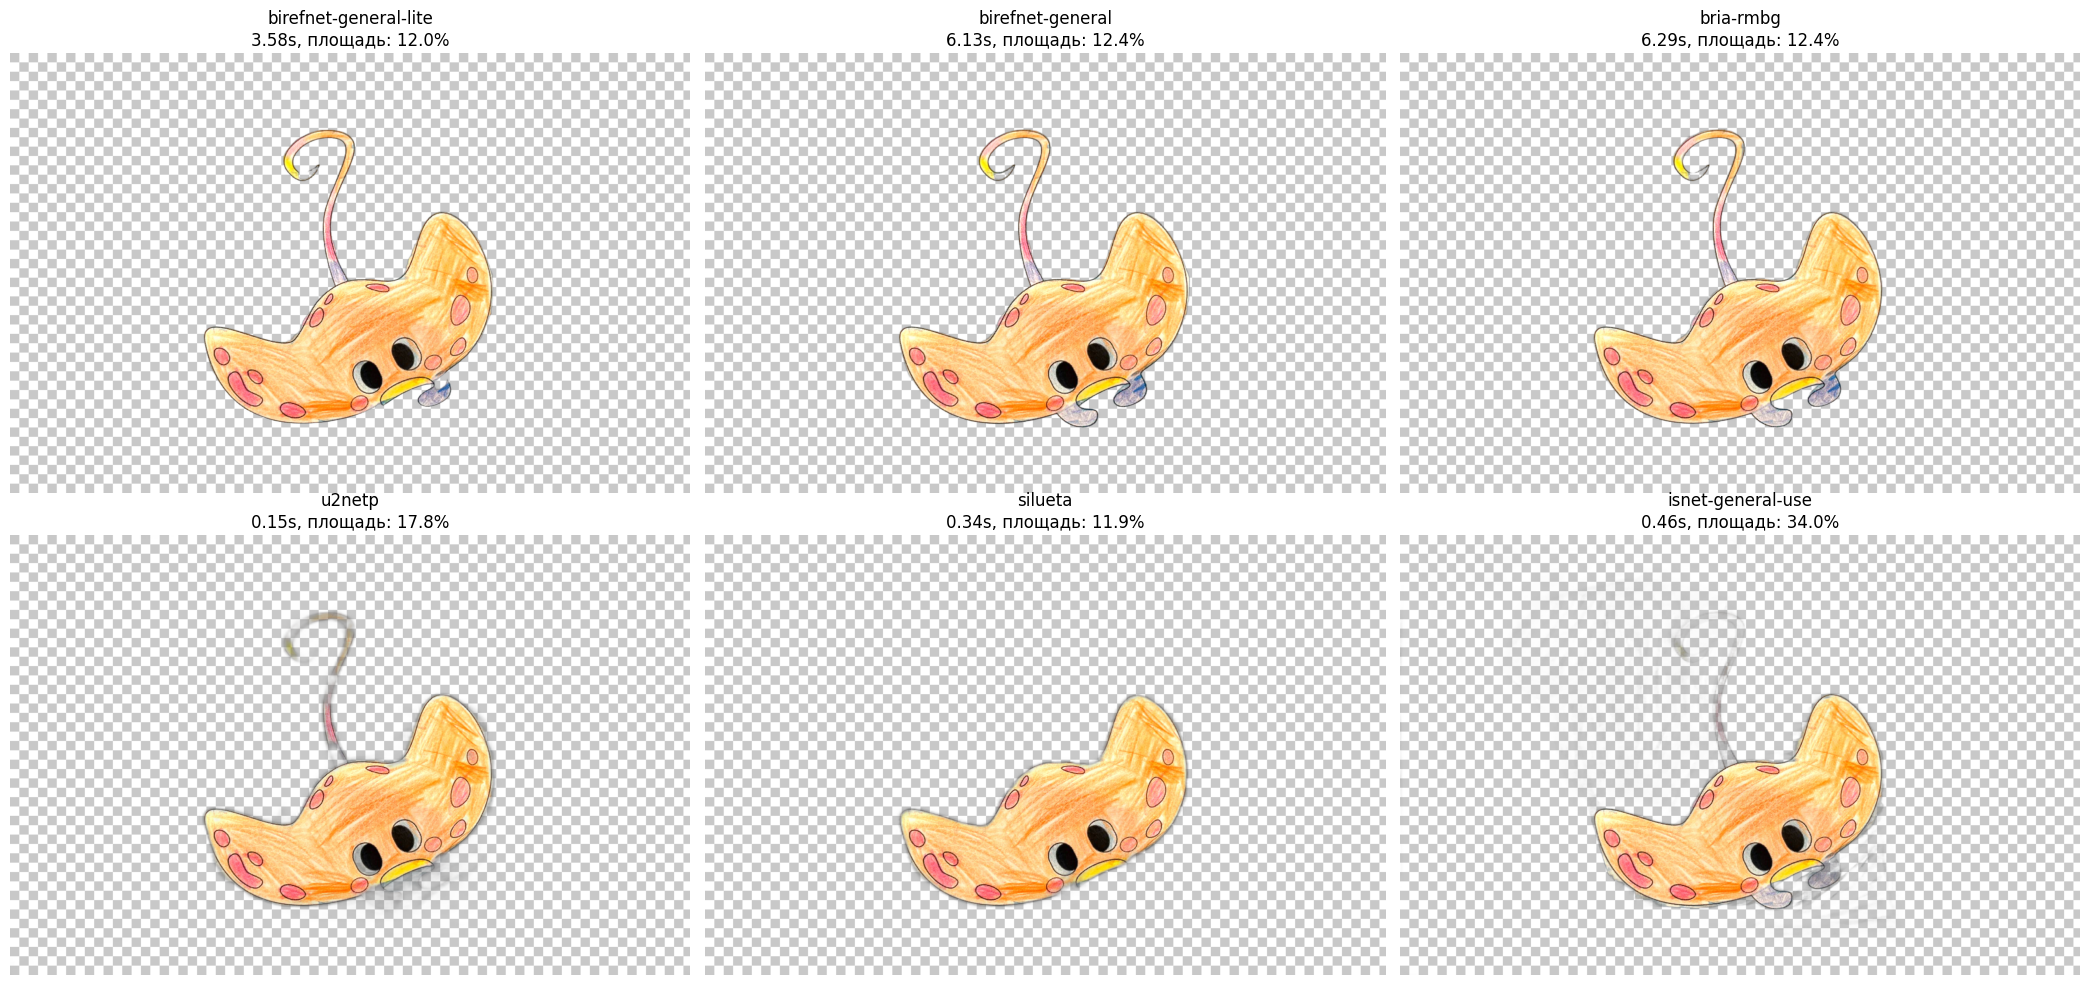

In [21]:
from rembg import new_session, remove
from tqdm.notebook import tqdm

models = [
    "birefnet-general-lite",  # BiRefNet лёгкая
    "birefnet-general",       # BiRefNet полная
    "bria-rmbg",              # лёгкая
    "u2netp",                 # лёгкий U2-Net
    "silueta",                # лёгкая
    "isnet-general-use",      # ISNet
]

ok, buf = cv2.imencode(".png", img)
img_bytes = buf.tobytes()

h, w = img.shape[:2]
checker = np.zeros((h, w, 3), dtype=np.uint8)
block = 20
for y in range(0, h, block):
    for x in range(0, w, block):
        if (y // block + x // block) % 2 == 0:
            checker[y:y+block, x:x+block] = 200
        else:
            checker[y:y+block, x:x+block] = 255

results = []
for model_name in tqdm(models, desc="rembg модели"):
    session = new_session(model_name)
    t0 = time.time()
    fg_png = remove(img_bytes, session=session)
    dt = time.time() - t0
    fg = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)
    rgba = cv2.cvtColor(fg, cv2.COLOR_BGRA2RGBA)
    mask = rgba[:, :, 3]
    area_pct = (mask > 0).sum() / mask.size * 100
    alpha = rgba[:, :, 3:] / 255.0
    vis = (rgba[:, :, :3] * alpha + checker * (1 - alpha)).astype(np.uint8)
    results.append((model_name, vis, dt, area_pct))

cols = 3
rows = (len(results) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes = axes.flatten()
for i, (name, vis, dt, area_pct) in enumerate(results):
    axes[i].imshow(vis)
    axes[i].set_title(f"{name}\n{dt:.2f}s, площадь: {area_pct:.1f}%")
    axes[i].axis("off")
for j in range(len(results), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

**transparent-background**

Settings -> Mode=base, Device=cuda:0, Torchscript=disabled


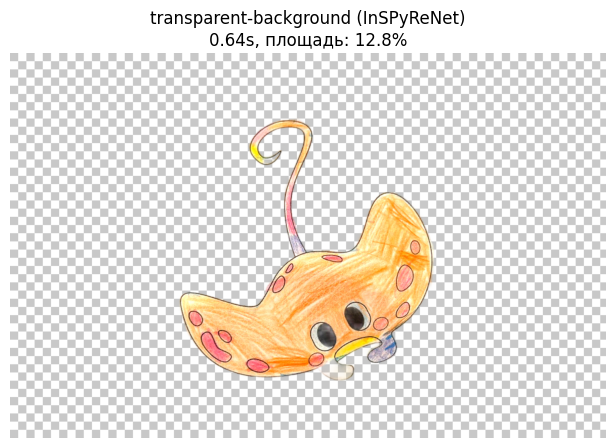

In [14]:
from transparent_background import Remover
from PIL import Image

remover = Remover(mode="base")

pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
t0 = time.time()
result = remover.process(pil_img, type="rgba")
dt = time.time() - t0

rgba = np.array(result)
mask = rgba[:, :, 3]
area_pct = (mask > 0).sum() / mask.size * 100

alpha = rgba[:, :, 3:] / 255.0
vis = (rgba[:, :, :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

plt.figure(figsize=(8, 5))
plt.imshow(vis)
plt.axis("off")
plt.title(f"transparent-background (InSPyReNet)\n{dt:.2f}s, площадь: {area_pct:.1f}%")
plt.show()

# OUTPUT

In [ ]:
import sys, time, glob, re
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from rembg import new_session, remove
from transparent_background import Remover
from PIL import Image
from tqdm.notebook import tqdm

sys.path.insert(0, "../pipeline")
from utils import transfer_color, image_rect_from_svg, template_meta

# --- входные картинки ---
inputs = sorted(glob.glob("input/seg_*.png"))
col_names = [Path(p).stem for p in inputs]
print(f"Картинок: {len(inputs)}: {col_names}")

# --- конфиг шаблона ---
CANVAS_SIZE = (1240, 1754)
MARKER_PX, MARGIN, CONTENT_PAD = 80, 60, 10
meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
bx, by, bw, bh = meta["drawing_bbox"]

# --- модели ---
rembg_models = [
    "birefnet-general",
    "birefnet-general-lite",
    "bria-rmbg",
    "isnet-general-use",
    "u2netp",
    "silueta",
]
tb_remover = Remover(mode="base")

row_labels = [
    ("Исходник", ""),
    ("SVG-маска", "pipeline"),
    ("birefnet-general", "rembg"),
    ("birefnet-general-lite", "rembg"),
    ("bria-rmbg", "rembg"),
    ("isnet-general-use", "rembg"),
    ("u2netp", "rembg"),
    ("silueta", "rembg"),
    ("InSPyReNet", "transparent-bg"),
]

# --- утилиты ---
def make_checker(h, w, block=20):
    ch = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(0, h, block):
        for x in range(0, w, block):
            ch[y:y+block, x:x+block] = 200 if (y // block + x // block) % 2 == 0 else 255
    return ch

def overlay_checker(rgba, checker):
    alpha = rgba[:, :, 3:] / 255.0
    return (rgba[:, :, :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

def char_id_from_path(path):
    m = re.search(r"seg_(\d+)", Path(path).stem)
    return m.group(1) if m else None

# --- прогон ---
grid = [[] for _ in inputs]

for col, img_path in enumerate(tqdm(inputs, desc="Картинки")):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    checker = make_checker(h, w)
    ok, buf = cv2.imencode(".png", img)
    img_bytes = buf.tobytes()
    char_id = char_id_from_path(img_path)

    # исходник
    grid[col].append((cv2.cvtColor(img, cv2.COLOR_BGR2RGB), None, None))

    # SVG-маска
    svg_path = f"../pipeline/templates/{char_id}/mask.svg"
    image_rect = image_rect_from_svg(svg_path, meta, content_scale=0.8)
    aligned_stub = np.full((CANVAS_SIZE[0], CANVAS_SIZE[1], 3), 255, dtype=np.uint8)
    aligned_stub[by:by+bh, bx:bx+bw] = img
    t0 = time.time()
    colored = transfer_color(aligned_stub, svg_path, image_rect)
    dt = time.time() - t0
    rgba = cv2.cvtColor(colored["rgba"], cv2.COLOR_BGRA2RGBA)
    rh, rw = rgba.shape[:2]
    area_pct = (rgba[:, :, 3] > 0).sum() / (rh * rw) * 100
    grid[col].append((overlay_checker(rgba, make_checker(rh, rw)), dt, area_pct))

    # rembg модели
    for model_name in rembg_models:
        try:
            session = new_session(model_name)
            t0 = time.time()
            fg_png = remove(img_bytes, session=session)
            dt = time.time() - t0
            fg = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)
            rgba = cv2.cvtColor(fg, cv2.COLOR_BGRA2RGBA)
            mask = rgba[:, :, 3]
            area_pct = (mask > 0).sum() / mask.size * 100
            grid[col].append((overlay_checker(rgba, checker), dt, area_pct))
        except Exception:
            grid[col].append((checker, 0, 0))

    # InSPyReNet
    pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    t0 = time.time()
    result = tb_remover.process(pil_img, type="rgba")
    dt = time.time() - t0
    rgba = np.array(result)
    mask = rgba[:, :, 3]
    area_pct = (mask > 0).sum() / mask.size * 100
    grid[col].append((overlay_checker(rgba, make_checker(*rgba.shape[:2])), dt, area_pct))

# --- визуализация (как в моке) ---
n_rows = len(row_labels)
n_cols = len(inputs)

img_ratio = grid[0][0][0].shape[1] / grid[0][0][0].shape[0]
cell_w = 2.8
cell_h = cell_w / img_ratio

BG_COLOR = "#1e1e2e"
CELL_BG = "#2a2a3d"
HEADER_BG = "#363650"
TEXT_COLOR = "#cdd6f4"
ACCENT = "#89b4fa"
GRID_COLOR = "#45475a"
INFO_COLOR = "#a6adc8"
SUB_COLOR = "#7f849c"

fig_w = cell_w * n_cols + 2.5
fig_h = cell_h * n_rows + 1.2

fig = plt.figure(figsize=(fig_w, fig_h), facecolor=BG_COLOR)
fig.suptitle("Сравнение методов сегментации персонажа",
             fontsize=16, fontweight="bold", color=TEXT_COLOR, y=0.995)

gs = gridspec.GridSpec(n_rows + 1, n_cols + 1,
                       width_ratios=[0.55] + [1] * n_cols,
                       height_ratios=[0.15] + [1] * n_rows,
                       wspace=0.05, hspace=0.10)

# заголовки столбцов
for c in range(n_cols):
    ax = fig.add_subplot(gs[0, c + 1])
    ax.set_facecolor(HEADER_BG)
    ax.text(0.5, 0.5, col_names[c], ha="center", va="center",
            fontsize=8, fontweight="bold", color=ACCENT, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color(GRID_COLOR)

# строки
for r in range(n_rows):
    name, pkg = row_labels[r]

    ax_label = fig.add_subplot(gs[r + 1, 0])
    ax_label.set_facecolor(BG_COLOR)
    ax_label.text(0.95, 0.5, name, ha="right", va="bottom" if pkg else "center",
                  fontsize=9, color=ACCENT if r == 0 else TEXT_COLOR,
                  fontweight="bold" if r == 0 else "normal",
                  transform=ax_label.transAxes)
    if pkg:
        ax_label.text(0.95, 0.46, pkg, ha="right", va="top",
                      fontsize=7, color=SUB_COLOR, transform=ax_label.transAxes)
    ax_label.set_xticks([]); ax_label.set_yticks([])
    for spine in ax_label.spines.values():
        spine.set_visible(False)

    for c in range(n_cols):
        ax = fig.add_subplot(gs[r + 1, c + 1])
        ax.set_facecolor(CELL_BG)

        vis, dt, area_pct = grid[c][r]
        ax.imshow(vis)

        if dt is not None:
            ax.text(0.5, -0.04, f"{dt:.2f}s | {area_pct:.0f}%",
                    ha="center", va="top", fontsize=7,
                    color=INFO_COLOR, transform=ax.transAxes)

        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color(GRID_COLOR)
            spine.set_linewidth(0.5)

ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(BG_COLOR)
ax0.axis("off")

Path("output").mkdir(exist_ok=True)
plt.savefig("output/seg_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Сохранено: output/seg_comparison.png")

**merge**

In [ ]:
import sys, time, glob, re
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "../pipeline")
from utils import transfer_color, image_rect_from_svg, template_meta

# --- конфиг шаблона ---
CANVAS_SIZE = (1240, 1754)
MARKER_PX, MARGIN, CONTENT_PAD = 80, 60, 10
meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
DRAW_BBOX = meta["drawing_bbox"]   # (bx, by, bw, bh)

# --- хелперы ---
def char_id_from_path(p):
    m = re.search(r"seg_(\d+)", Path(p).stem)
    return m.group(1) if m else None

def svg_path_for(p):
    return f"../pipeline/templates/{char_id_from_path(p)}/mask.svg"

def make_checker(h, w, block=20):
    ch = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(0, h, block):
        for x in range(0, w, block):
            ch[y:y+block, x:x+block] = 200 if (y // block + x // block) % 2 == 0 else 255
    return ch

def overlay_checker(rgba, checker=None):
    if checker is None:
        checker = make_checker(*rgba.shape[:2])
    alpha = rgba[:, :, 3:] / 255.0
    return (rgba[:, :, :3] * alpha + checker * (1 - alpha)).astype(np.uint8)

def mask_bbox(mask):
    ys, xs = np.where(mask > 0)
    return int(xs.min()), int(ys.min()), int(xs.max()-xs.min()+1), int(ys.max()-ys.min()+1)

# --- пробник ---
PROBE_PATH = "input/seg_003_test1.png"   # меняй на любой seg_*.png где видно проблему
probe_img = cv2.imread(PROBE_PATH)
probe_rgb = cv2.cvtColor(probe_img, cv2.COLOR_BGR2RGB)
char_id = char_id_from_path(PROBE_PATH)
svg_path = svg_path_for(PROBE_PATH)

# image_rect в канвасе + перевод в координаты пробника
image_rect = image_rect_from_svg(svg_path, meta, content_scale=0.8)

print(f"Пробник: {Path(PROBE_PATH).name}, char_id={char_id}")
print(f"Размер пробника: {probe_img.shape[1]}×{probe_img.shape[0]}")
print(f"DRAW_BBOX: {DRAW_BBOX}")
print(f"image_rect: {image_rect}")

plt.figure(figsize=(6, 4))
plt.imshow(probe_rgb); plt.axis("off"); plt.title("aligned crop")
plt.show()


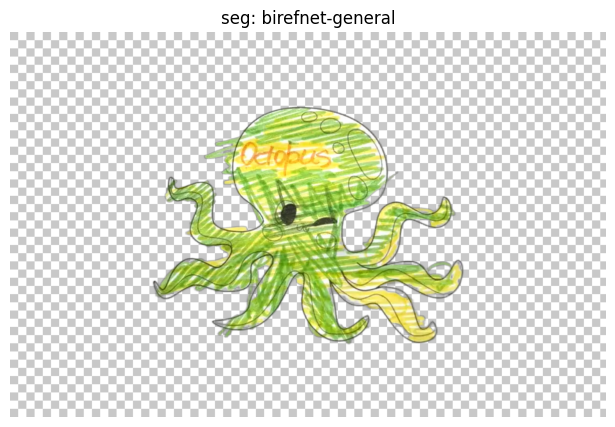

In [2]:
from rembg import new_session, remove

SEG_MODEL = "birefnet-general"

def segment_rgba(bgr, model_name=SEG_MODEL, _cache={}):
    if model_name not in _cache:
        _cache[model_name] = new_session(model_name)
    ok, buf = cv2.imencode(".png", bgr)
    fg_png = remove(buf.tobytes(), session=_cache[model_name])
    bgra = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)
    return cv2.cvtColor(bgra, cv2.COLOR_BGRA2RGBA)

rgba_seg = segment_rgba(probe_img)
mask_seg = rgba_seg[:, :, 3]

plt.figure(figsize=(8, 5))
plt.imshow(overlay_checker(rgba_seg))
plt.axis("off"); plt.title(f"seg: {SEG_MODEL}")
plt.show()


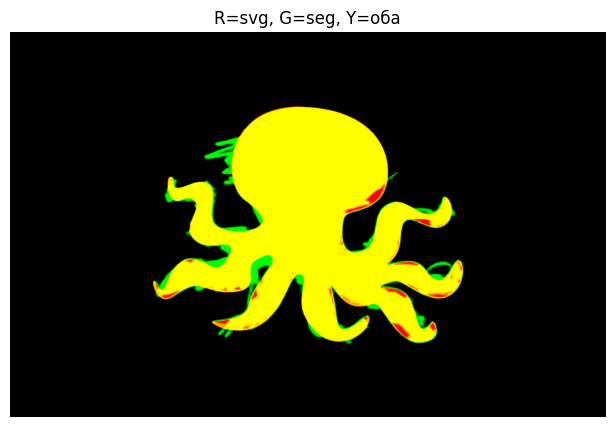

In [3]:
# --- альфа из transfer_color (размер image_rect) ---
bx, by, bw, bh = DRAW_BBOX
ix, iy, iw, ih = image_rect

aligned_stub = np.full((CANVAS_SIZE[0], CANVAS_SIZE[1], 3), 255, dtype=np.uint8)
aligned_stub[by:by+bh, bx:bx+bw] = probe_img
colored = transfer_color(aligned_stub, svg_path, image_rect)
svg_alpha = colored["rgba"][:, :, 3]

# --- кладём в пробник со сдвигом ---
mask_svg_bin = np.zeros((bh, bw), dtype=np.uint8)
mask_svg_bin[iy-by:iy-by+ih, ix-bx:ix-bx+iw] = (svg_alpha > 127).astype(np.uint8) * 255

# --- сравнение силуэтов: R=svg, G=seg, Y=both ---
overlay = np.zeros((bh, bw, 3), dtype=np.uint8)
overlay[..., 0] = mask_svg_bin
overlay[..., 1] = mask_seg

plt.figure(figsize=(8, 5))
plt.imshow(overlay); plt.axis("off")
plt.title("R=svg, G=seg, Y=оба")
plt.show()


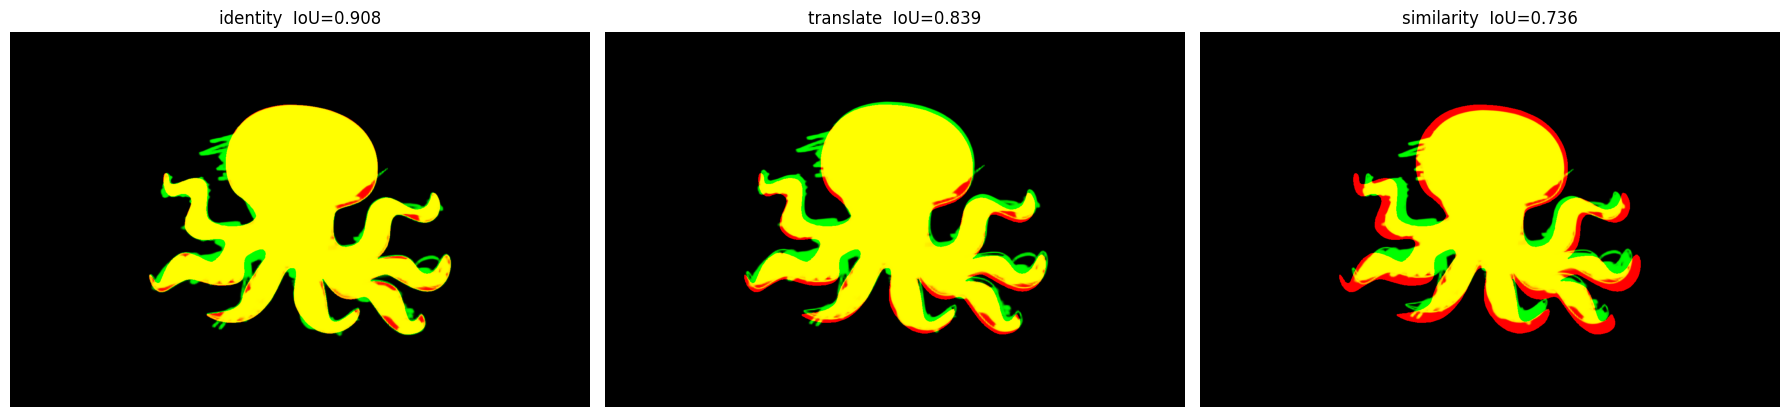

выбран: identity  IoU=0.908


In [4]:
# --- моменты и bbox'ы ---
def centroid_area(mask):
    m = cv2.moments((mask > 0).astype(np.uint8))
    return m["m10"]/m["m00"], m["m01"]/m["m00"], m["m00"]

seg_cx, seg_cy, seg_area = centroid_area(mask_seg)
svg_cx, svg_cy, svg_area = centroid_area(mask_svg_bin)

# --- 3 стратегии: identity / translate / similarity ---
strategies = {
    "identity":   np.float32([[1, 0, 0], [0, 1, 0]]),
    "translate":  np.float32([[1, 0, svg_cx-seg_cx], [0, 1, svg_cy-seg_cy]]),
}
scale = np.sqrt(svg_area / seg_area)
strategies["similarity"] = np.float32([
    [scale, 0, svg_cx - scale*seg_cx],
    [0, scale, svg_cy - scale*seg_cy],
])

# --- сравниваем по IoU ---
h, w = rgba_seg.shape[:2]
results = {}
for name, M in strategies.items():
    warped = cv2.warpAffine(rgba_seg, M, (w, h), borderValue=(0,0,0,0))
    inter = ((mask_svg_bin > 0) & (warped[:,:,3] > 128)).sum()
    union = ((mask_svg_bin > 0) | (warped[:,:,3] > 128)).sum()
    results[name] = (warped, inter / max(1, union))

# --- визуализация ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (warped, iou)) in zip(axes, results.items()):
    ov = np.zeros((h, w, 3), dtype=np.uint8)
    ov[..., 0] = mask_svg_bin
    ov[..., 1] = warped[:, :, 3]
    ax.imshow(ov); ax.set_title(f"{name}  IoU={iou:.3f}"); ax.axis("off")
plt.tight_layout(); plt.show()

best_name = max(results, key=lambda n: results[n][1])
rgba_aligned = results[best_name][0]
print(f"выбран: {best_name}  IoU={results[best_name][1]:.3f}")

In [ ]:
# --- новый результат: aligned seg → canvas ---
canvas_h, canvas_w = CANVAS_SIZE[0], CANVAS_SIZE[1]
result_seg = np.zeros((canvas_h, canvas_w, 4), dtype=np.uint8)
bx, by, bw, bh = DRAW_BBOX
result_seg[by:by+bh, bx:bx+bw] = rgba_aligned

# --- baseline: transfer_color → canvas ---
result_svg = np.zeros((canvas_h, canvas_w, 4), dtype=np.uint8)
ix, iy, iw, ih = image_rect
result_svg[iy:iy+ih, ix:ix+iw] = cv2.cvtColor(colored["rgba"], cv2.COLOR_BGRA2RGBA)

# --- показ ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(overlay_checker(result_svg))
axes[0].set_title("baseline: transfer_color (SVG mask)"); axes[0].axis("off")
axes[1].imshow(overlay_checker(result_seg))
axes[1].set_title(f"new: seg + {best_name}"); axes[1].axis("off")
plt.tight_layout(); plt.show()


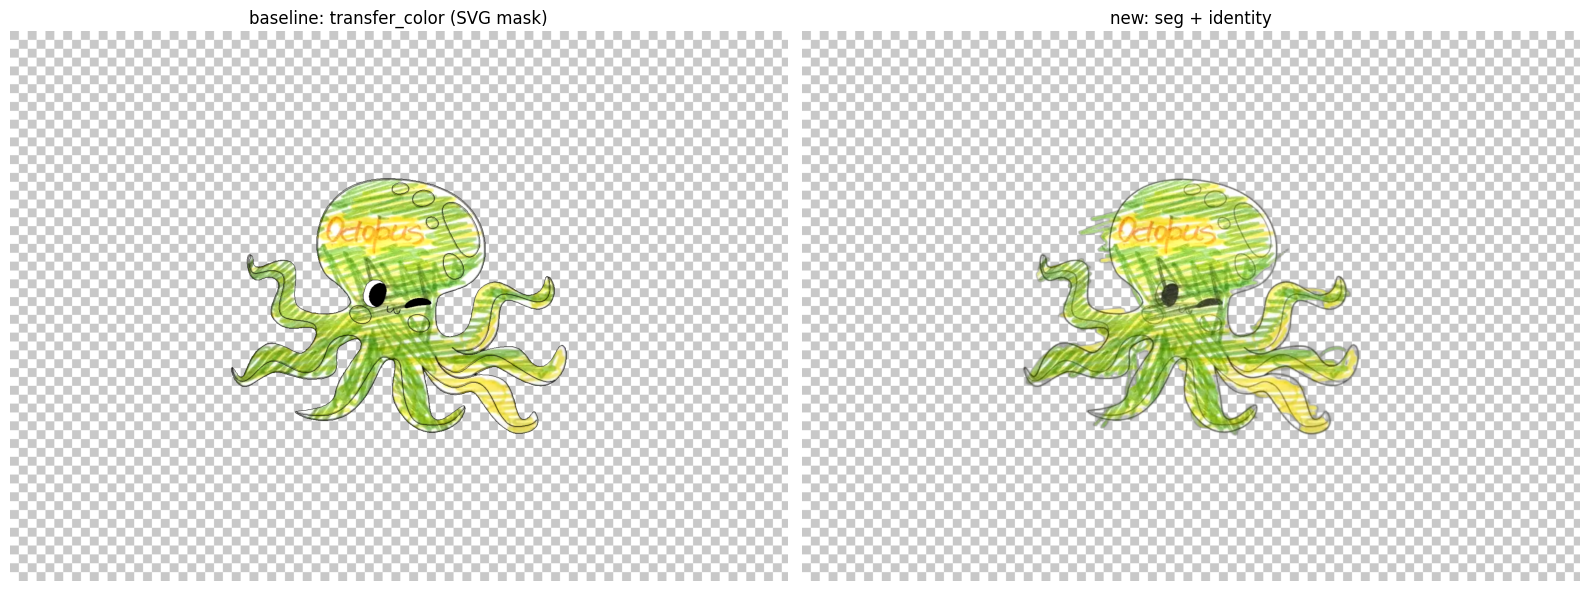

In [ ]:
# SVG cut (baseline) vs segmentation + warp + SVG clip (новый)
#
# ┌────────────────────┬──────────────────────┬──────────────────────────┐
# │ аспект             │ SVG cut (baseline)   │ seg + warp + clip        │
# ├────────────────────┼──────────────────────┼──────────────────────────┤
# │ контур             │ двойной при съезде   │ один чистый              │
# │ скорость           │ мгновенно            │ ~10s/картинку            │
# │ failure mode       │ понятен (ghost edge) │ black box (нейронка)     │
# │ как чинить         │ переснять/разгладить │ сменить модель или жить  │
# │ детекция на входе  │ можно мерить ArUco   │ качество видно постфактум│
# │ сложность флоу     │ минимум              │ +сегментация, +warp      │
# └────────────────────┴──────────────────────┴──────────────────────────┘


In [7]:
import pandas as pd

compare = pd.DataFrame([
    ("контур",             "двойной при съезде",   "один чистый"),
    ("печатная линия",     "чистая (из SVG)",      "фото-версия (неровная)"),
    ("детали внутри",      "точно по SVG painter", "из RGB как есть"),
    ("скорость",           "мгновенно",             "~10s / картинку"),
    ("ресурсы",            "cv2+lxml (MB)",         "torch+модели (сотни MB)"),
    ("воспроизводимость",  "детерминирован",        "зависит от весов модели"),
    ("свет/тени",          "пофиг",                 "может сбить модель"),
    ("failure mode",       "понятен (ghost edge)",  "black box"),
    ("как чинить сбой",    "переснять/разгладить",  "сменить модель или жить"),
    ("детекция на входе",  "можно измерить ArUco",  "видно только постфактум"),
    ("authoring control",  "полный через SVG",      "минимальный"),
    ("сложность флоу",     "минимум",               "+seg, +warp, +clip"),
], columns=["аспект", "SVG cut (baseline)", "seg + warp + clip"]).set_index("аспект")
compare


,SVG cut (baseline),seg + warp + clip
аспект,,
контур,двойной при съезде,один чистый
печатная линия,чистая (из SVG),фото-версия (неровная)
детали внутри,точно по SVG painter,из RGB как есть
скорость,мгновенно,~10s / картинку
ресурсы,cv2+lxml (MB),torch+модели (сотни MB)
воспроизводимость,детерминирован,зависит от весов модели
свет/тени,пофиг,может сбить модель
failure mode,понятен (ghost edge),black box
как чинить сбой,переснять/разгладить,сменить модель или жить


In [ ]:
# Подход: segmentation + rigid align вместо SVG-маски.
#
# 1. birefnet-general сегментирует персонажа → одинарный контур (нет "двойника"
#    как у transfer_color, где маска шаблона не совпадает с детской обводкой).
# 2. Строим SVG-маску в координатах пробника как референс: "где перс по шаблону".
# 3. Пробуем 3 варианта трансформа seg → svg:
#      identity   — не двигаем
#      translate  — сдвиг по центроидам (moments)
#      similarity — сдвиг + scale = sqrt(svg_area / seg_area)
# 4. Выбираем с максимальным IoU(warped_seg, svg_mask) — адаптивно:
#    если seg хороший → identity победит, warp не применяется;
#    если есть лёгкий съезд → similarity чинит.
# 5. Кладём rgba_aligned на канвас в DRAW_BBOX.


In [ ]:
# Минусы подхода:
# - Сегментация может ошибиться: проглотить часть тела или захватить шум.
#   Warp это не починит — скорее усугубит.
# - Время: birefnet-general ~10s/картинка. Лёгкие модели быстрее, но края хуже.
# - Warp покрывает translate + uniform scale. Поворот и non-rigid искажения
#   (кривые пропорции, сильно съехавшие части) не чиним.
# - Выбор по IoU по общему силуэту — локальные мисматчи (одна рука уехала)
#   усредняются, и warp может не выбрать оптимум именно для проблемной зоны.
# - Не сглаживаем рваную границу сегментации — контур дрожит как у карандаша.
# - Используем только бинарный силуэт SVG, игнорируя fill-зоны и обводки.
